# Task 0 · Gradient boosting baseline

The team's reference model, built on the shared benchmark in [`forecast/`](forecast/). See [`TASK0_README.md`](TASK0_README.md) for the rules and the evaluation.

- **Day-ahead rule:** the forecast for day D is made at the end of day D-1. It uses load and weather up to D-1, nothing from day D.
- **Data processing choice:** `Config(weather_resampling=...)` sets how hourly weather becomes 15-min values, `"step"` or `"interpolate"`.
- **Output:** `evaluate.submit` scores the predictions and adds a row to `results/leaderboard.csv`.

Runtime ≈ 3 min (the first run also builds `cache/`), peak memory ≈ 6 GB.

In [1]:
from sklearn.ensemble import HistGradientBoostingRegressor

from forecast import Config, baselines, evaluate, features

config = Config(weather_resampling="step")  # "step" or "interpolate"
NAME = f"gbm_{config.weather_resampling}"  # unique name on the leaderboard
AUTHOR = "pengxuanHuang"
MODEL_PARAMS = dict(max_iter=300, learning_rate=0.1, categorical_features="from_dtype", random_state=0)

## 1. Standard features

In [2]:
df = features.build_features(config)
FEATURES = features.standard_features()
train, test = features.split(df, config)
print(f"{len(FEATURES)} features · train sample {len(train):,} rows · test {len(test):,} rows")
FEATURES

26 features · train sample 3,000,000 rows · test 12,471,135 rows


['temperature_1d',
 'temperature_day_mean_1d',
 'sunshine_1d',
 'humidity_1d',
 'wind_speed_1d',
 'sunshine_filled_1d',
 'quarter_hour',
 'weekday',
 'month',
 'kwh_lag_1d',
 'kwh_lag_7d',
 'is_treatment',
 'after_visit',
 'has_pv',
 'Survey_Building_LivingArea',
 'Survey_Building_Residents',
 'Survey_Building_Type',
 'Survey_HeatPump_Installation_Type',
 'Survey_HeatDistribution_System_FloorHeating',
 'Survey_HeatDistribution_System_Radiator',
 'Survey_DHW_Production_ByHeatPump',
 'Survey_DHW_Production_ByElectricWaterHeater',
 'Survey_DHW_Production_BySolar',
 'Survey_Installation_HasDryer',
 'Survey_Installation_HasFreezer',
 'Survey_Installation_HasElectricVehicle']

## 2. Train

In [3]:
model = HistGradientBoostingRegressor(**MODEL_PARAMS)
model.fit(train[FEATURES], train["kwh"])

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


## 3. Predict and submit

In [4]:
predictions = test[["Household_ID", "Timestamp"]].assign(prediction=model.predict(test[FEATURES]).clip(min=0))
evaluate.submit(predictions, NAME, AUTHOR,
                description=f"HistGradientBoosting, standard features, weather {config.weather_resampling}",
                config=config.to_dict(), params=MODEL_PARAMS)

Submitted 'gbm_step'. Portfolio nMAE: 11.64 % per 15 min, 7.79 % per day


,MAE,RMSE,nMAE,bias
portfolio_15min,11.684,16.483,11.641,0.864
portfolio_day,749.871,1104.726,7.790,0.861
household_15min,0.175,0.287,62.467,0.864
household_day,5.775,8.901,21.444,0.861


## 4. Reference baselines

Naive forecasts every model should beat. They only need to be submitted once, but re-running is cheap.

In [5]:
evaluate.submit(baselines.naive(df, "kwh_lag_1d"), "naive_lag_1d", "reference",
                "Same 15 min yesterday (fallback: 7 days ago, household profile)")
evaluate.submit(baselines.naive(df, "kwh_lag_7d"), "naive_lag_7d", "reference",
                "Same 15 min one week ago (fallback: yesterday, household profile)")

Submitted 'naive_lag_1d'. Portfolio nMAE: 13.41 % per 15 min, 7.90 % per day


Submitted 'naive_lag_7d'. Portfolio nMAE: 20.45 % per 15 min, 16.92 % per day


,MAE,RMSE,nMAE,bias
portfolio_15min,20.528999,30.042999,20.454000,0.602
portfolio_day,1628.862061,2459.916992,16.921000,0.521
household_15min,0.205000,0.380000,73.035004,0.602
household_day,7.871000,12.724000,29.228001,0.521


## 5. Leaderboard

In [6]:
evaluate.leaderboard()

,author,date,description,portfolio_15min_nMAE,portfolio_15min_bias,portfolio_day_nMAE,portfolio_day_bias,household_15min_nMAE,household_15min_bias,household_day_nMAE,household_day_bias
name,,,,,,,,,,,
gbm_step,pengxuanHuang,2026-10-06 16:56,"HistGradientBoosting, standard features, weath...",11.64,0.86,7.79,0.86,62.47,0.86,21.44,0.86
gbm_interpolate,pengxuanHuang,2026-10-06 16:53,"HistGradientBoosting, standard features, weath...",11.68,0.82,7.84,0.82,62.50,0.82,21.53,0.82
naive_lag_1d,reference,2026-10-06 16:56,"Same 15 min yesterday (fallback: 7 days ago, h...",13.41,0.28,7.90,0.20,69.23,0.28,20.34,0.20
linear_example,your-name,2026-10-06 16:54,Linear regression on numeric standard features...,13.43,2.23,8.74,2.22,65.71,2.23,23.42,2.22
naive_lag_7d,reference,2026-10-06 16:56,"Same 15 min one week ago (fallback: yesterday,...",20.45,0.60,16.92,0.52,73.03,0.60,29.23,0.52


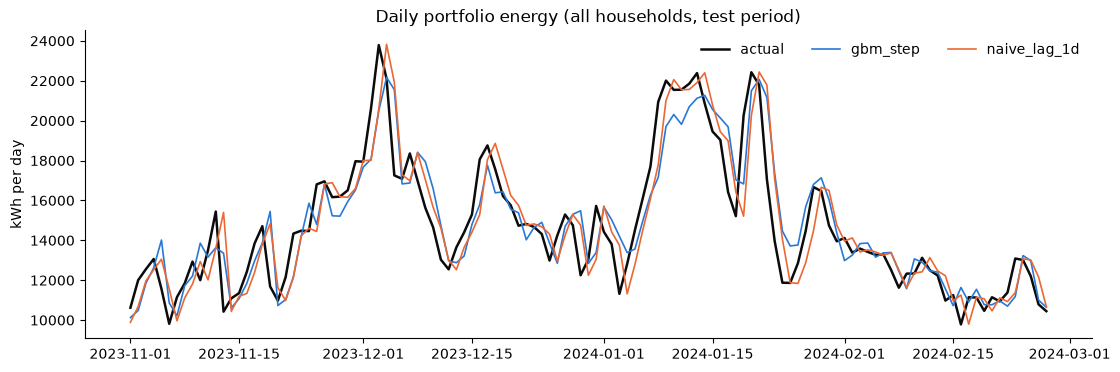

In [7]:
evaluate.plot_daily([NAME, "naive_lag_1d"], start="2023-11-01")